In [1]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel('hr_cleaned.xlsx')
# Si guardaste en Excel usa:
# df = pd.read_excel('hr_cleaned.xlsx')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike (%),PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales executive,4.0,Single,5993.0,19479,8,Yes,11,3,1,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research scientist,2.0,Married,5130.0,24907,1,No,23,4,4,1,10,3.0,3,10,7,1,7.0
2,37.0,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory technician,3.0,Single,2090.0,2396,6,Yes,15,3,2,0,7,3.0,3,0,0,0,0.0
3,33.0,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research scientist,3.0,Married,2909.0,23159,1,Yes,11,3,3,0,8,3.0,3,8,7,3,0.0
4,27.0,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory technician,2.0,Married,3468.0,16632,9,No,12,3,4,1,6,3.0,3,2,2,2,2.0


## ANALISIS

- ¿Quien se va?

In [3]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [4]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

- El porcentaje de empleados abandona la empresa: 16%

# ¿Los empleados jóvenes abandonan más?

In [5]:
df.groupby("Attrition")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1177.0,37.553101,8.847582,18.0,31.0,36.0,43.0,60.0
Yes,220.0,33.677273,9.710439,18.0,28.0,32.0,39.0,58.0


<Axes: xlabel='Age', ylabel='Attrition'>

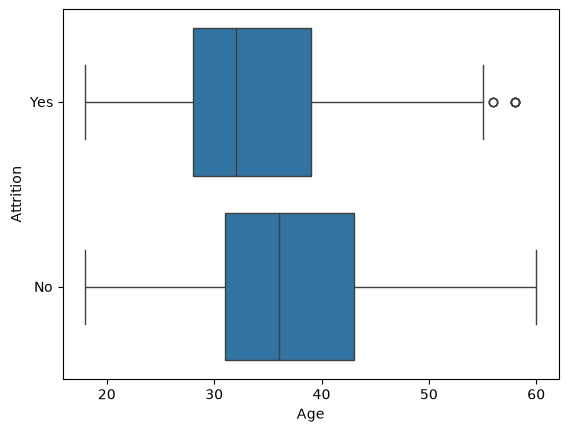

In [6]:
sns.boxplot(data=df,
            y="Attrition",
            x="Age")

In [7]:
df.groupby("Attrition")["Age"].mean()

Attrition
No     37.553101
Yes    33.677273
Name: Age, dtype: float64

-La media de edad de los empleados que se van es de  33 años 

# ¿Cobrar poco influye? *

<Axes: xlabel='MonthlyIncome', ylabel='Attrition'>

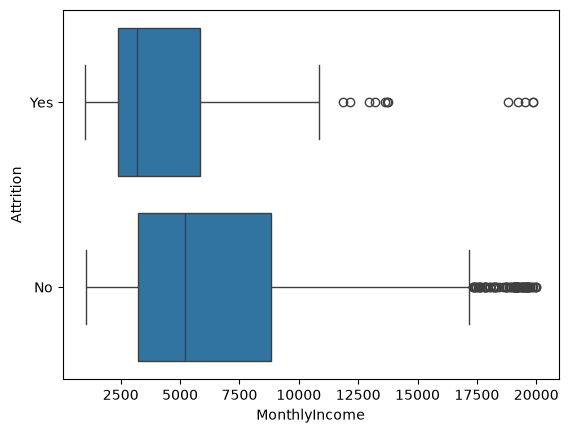

In [8]:
sns.boxplot(
    data=df,
    y="Attrition",
    x="MonthlyIncome"
)

In [9]:
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1223.0,6830.937040,4818.188433,1051.0,3210.5,5204.0,8835.5,19999.0
Yes,233.0,4754.708155,3630.120692,1009.0,2367.0,3202.0,5828.0,19859.0


In [10]:
df.groupby("Attrition")["MonthlyIncome"].median()

Attrition
No     5204.0
Yes    3202.0
Name: MonthlyIncome, dtype: float64

In [11]:
df.groupby("Attrition")["MonthlyIncome"].apply(lambda x: x.mode()[0] if len(x.mode()) > 0 else None)

Attrition
No     2342.0
Yes    2293.0
Name: MonthlyIncome, dtype: float64

- Los empleados que abandonan la empresa perciben un salario inferior al del resto de empleados

# Horas extra

<Axes: xlabel='OverTime', ylabel='count'>

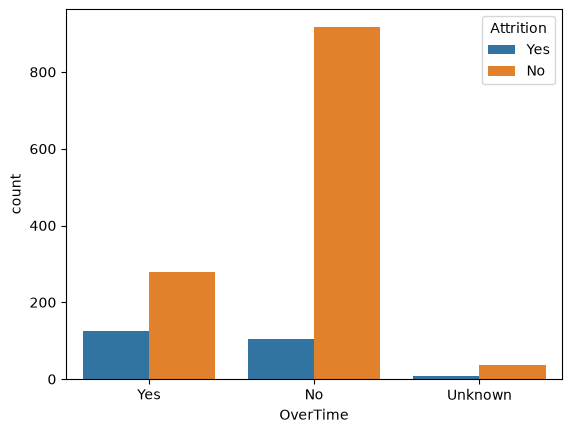

In [12]:
sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

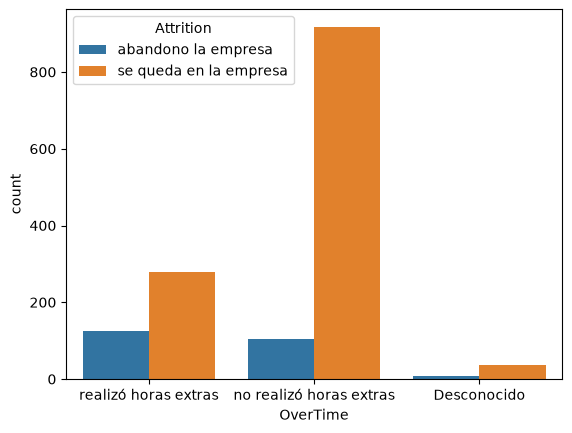

In [13]:
sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)
ax = plt.gca()
# renombrar etiquetas del eje x
xticks = [t.get_text() for t in ax.get_xticklabels()]
xt_map = {'Yes': 'realizó horas extras', 'No': 'no realizó horas extras', 'Unknown': 'Desconocido'}
ax.set_xticklabels([xt_map.get(t, t) for t in xticks])

# renombrar etiquetas de la leyenda (hue)
handles, labels = ax.get_legend_handles_labels()
legend_map = {'Yes': 'abandono la empresa', 'No': 'se queda en la empresa'}
ax.legend(handles=handles, labels=[legend_map.get(l, l) for l in labels], title='Attrition')

In [14]:
pd.crosstab(df["OverTime"],
            df["Attrition"],
            normalize="index")*100

Attrition,No,Yes
OverTime,,
No,89.813908,10.186092
Unknown,81.818182,18.181818
Yes,69.135802,30.864198


- Entre los empleados que no realizan horas extra, únicamente el 10 % abandona la empresa. En cambio, entre quienes sí realizan horas extra, el abandono asciende al 30 %

# Satisfacción laboral *

In [15]:
pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
JobSatisfaction,,
1.0,77.385159,22.614841
2.0,83.272727,16.727273
3.0,83.644860,16.355140
4.0,88.791209,11.208791


In [16]:
df_attrition_yes = df[df['Attrition'] == 'Yes']
df_attrition_no = df[df['Attrition'] == 'No']

<Axes: xlabel='JobSatisfaction', ylabel='count'>

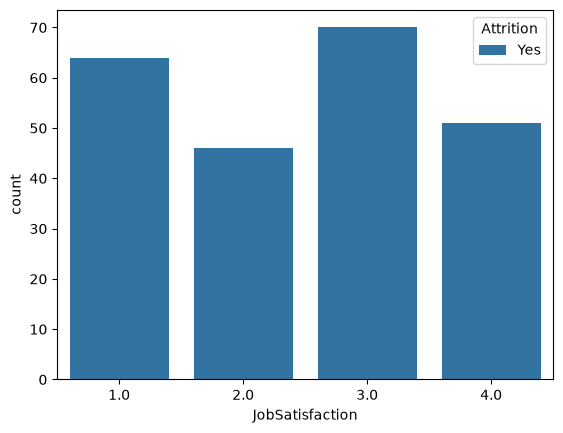

In [17]:
sns.countplot(
    data=df_attrition_yes,
    x="JobSatisfaction",
    hue="Attrition"
)

In [18]:
(df_attrition_yes['JobSatisfaction'].value_counts(normalize=True).sort_index() * 100).round(2)


JobSatisfaction
1.0    27.71
2.0    19.91
3.0    30.30
4.0    22.08
Name: proportion, dtype: float64

In [19]:
(df_attrition_no['JobSatisfaction'].value_counts(normalize=True).sort_index() * 100).round(2)

JobSatisfaction
1.0    18.10
2.0    18.93
3.0    29.59
4.0    33.39
Name: proportion, dtype: float64

 ¿La gente menos satisfecha se marcha más? SI . El 27,71 % de los empleados con satisfacción 1 abandonan la empresa, mientras que el 22,08 % de los empleados con satisfacción 4 lo hacen.

In [20]:
# El análisis de la satisfacción laboral muestra que los empleados que abandonan la empresa tienen una mayor proporción de insatisfacción laboral en comparación con aquellos que permanecen en la empresa. 
# Esto sugiere que la satisfacción laboral podría ser un factor importante en la retención de empleados.

In [21]:
# El 48% de los empleados que abandonan la empresa tienen un nivel de satisfaccion laboral de 1 y 2. Mientras que el 36% de los empleados que permanecen en la empresa tienen un nivel de satisfaccion laboral de 1 y 2. Esto indica que la insatisfacción laboral es más prevalente entre los empleados que abandonan la empresa, lo que podría ser un indicador clave para la gestión de recursos humanos y la implementación de estrategias de retención.

# Work Life Balance

<Axes: xlabel='WorkLifeBalance', ylabel='count'>

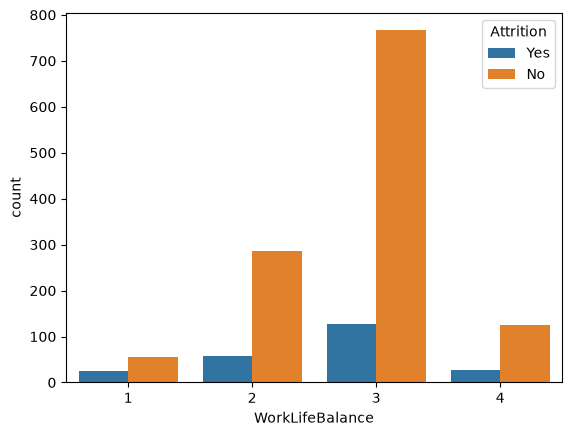

In [22]:
sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

- 

# Environment Satisfaction *

In [23]:
pd.crosstab(
    df["EnvironmentSatisfaction"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
EnvironmentSatisfaction,,
1,74.647887,25.352113
2,85.017422,14.982578
3,86.313466,13.686534
4,86.547085,13.452915


<Axes: xlabel='EnvironmentSatisfaction', ylabel='count'>

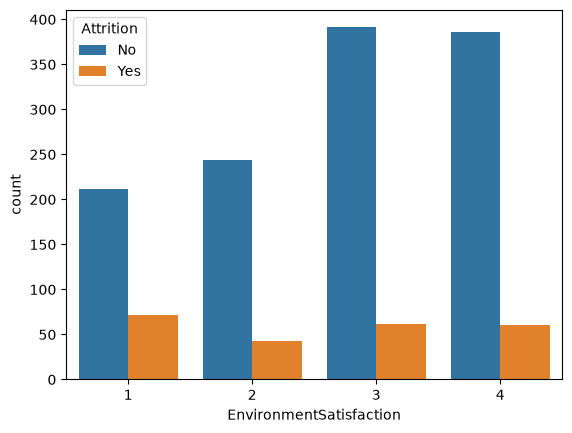

In [24]:
sns.countplot(
    data=df,
    x="EnvironmentSatisfaction",
    hue="Attrition"
)

- 

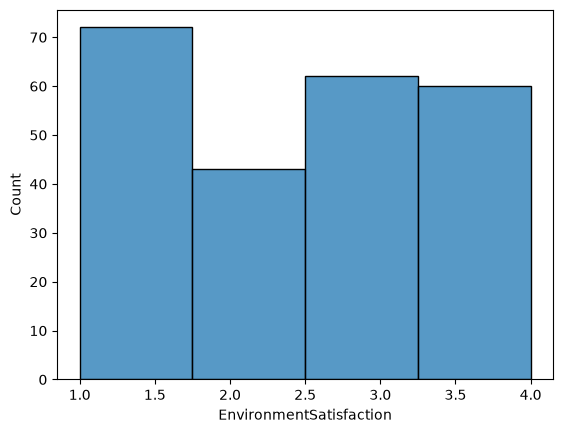

In [25]:
sns.histplot(data=df_attrition_yes, x='EnvironmentSatisfaction', bins=4)
plt.show()

In [26]:
(df_attrition_yes['EnvironmentSatisfaction'].value_counts(normalize=True).sort_index() * 100).round(2)

EnvironmentSatisfaction
1    30.38
2    18.14
3    26.16
4    25.32
Name: proportion, dtype: float64

In [27]:
(df_attrition_no['EnvironmentSatisfaction'].value_counts(normalize=True).sort_index() * 100).round(2)

EnvironmentSatisfaction
1    17.19
2    19.79
3    31.71
4    31.31
Name: proportion, dtype: float64

In [28]:
# El 48% de los empleados que abandonan la empresa tienen un nivel de satisfaccion laboral de 1 y 2. Mientras que el 37% de los empleados que permanecen en la empresa tienen un nivel de satisfaccion laboral de 1 y 2. Esto indica que la insatisfacción laboral es más prevalente entre los empleados que abandonan la empresa, lo que podría ser un indicador clave para la gestión de recursos humanos y la implementación de estrategias de retención.

# Job Involvement

In [29]:
pd.crosstab(
    df["JobInvolvement"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
JobInvolvement,,
1,66.265060,33.734940
2,81.066667,18.933333
3,85.599078,14.400922
4,90.972222,9.027778


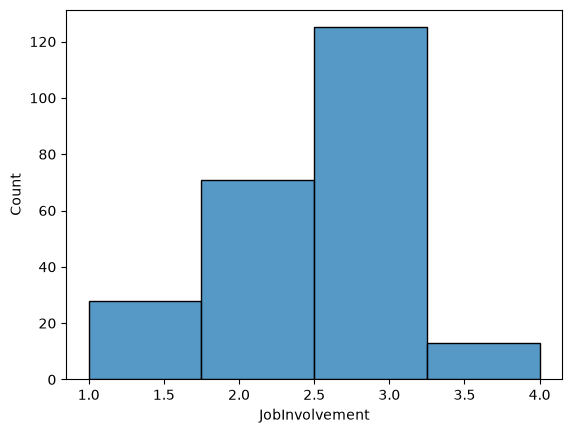

In [30]:
sns.histplot(data=df_attrition_yes, x='JobInvolvement', bins=4)
plt.show()

In [31]:
(df_attrition_yes['JobInvolvement'].value_counts(normalize=True).sort_index() * 100).round(2)

JobInvolvement
1    11.81
2    29.96
3    52.74
4     5.49
Name: proportion, dtype: float64

In [32]:
(df_attrition_no['JobInvolvement'].value_counts(normalize=True).sort_index() * 100).round(2)

JobInvolvement
1     4.46
2    24.66
3    60.26
4    10.62
Name: proportion, dtype: float64

# Departamento que pierde mas empleados *

In [ ]:
#tasa abandono por departamento
pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.131387,13.868613
Sales,79.372197,20.627803
Unknown,100.000000,0.000000


In [34]:
df['Department'].value_counts()

Department
Research & Development    959
Sales                     446
Human Resources            63
Unknown                     2
Name: count, dtype: int64

<Axes: xlabel='Department', ylabel='count'>

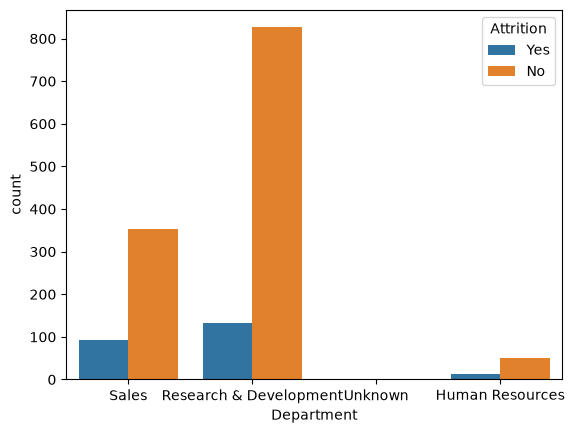

In [35]:
sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

- se aprecia clarmente que el departamento de Research & Development es el pierde mayor cantidad de empleados

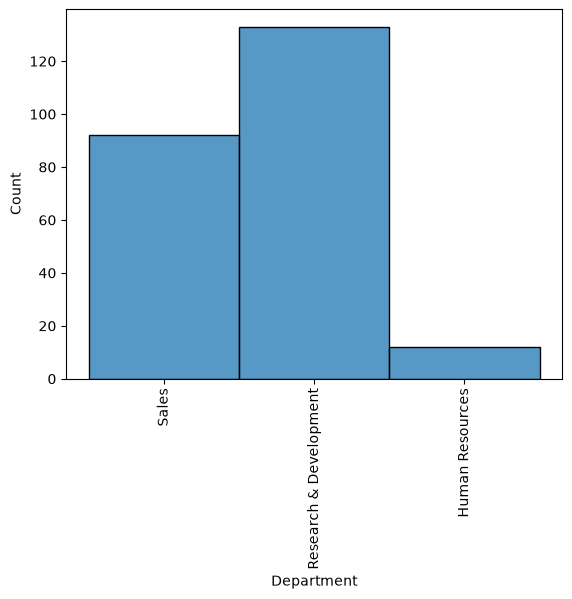

In [36]:
sns.histplot(data=df_attrition_yes, x='Department', bins=4)
plt.xticks(rotation=90)
plt.show()

In [37]:
(df_attrition_no['Department'].value_counts(normalize=True).sort_index() * 100).round(2)

Department
Human Resources            4.14
Research & Development    66.99
Sales                     28.71
Unknown                    0.16
Name: proportion, dtype: float64

In [ ]:
#bajas por departamento
(df_attrition_yes['Department'].value_counts(normalize=True).sort_index() * 100).round(2)

Department
Human Resources            5.06
Research & Development    56.12
Sales                     38.82
Name: proportion, dtype: float64

In [62]:
(df.query("Attrition == 'Yes'")
   .groupby("Department")
   .size()
   .div(len(df))
   .mul(100)
   .round(2))

Department
Human Resources           0.82
Research & Development    9.05
Sales                     6.26
dtype: float64

# Puesto

In [39]:
df.groupby("Department")["JobRole"].value_counts()

Department              JobRole                  
Human Resources         Human resources               52
                        Manager                       11
Research & Development  Research scientist           292
                        Laboratory technician        259
                        Manufacturing director       145
                        Healthcare representative    131
                        Research director             80
                        Manager                       52
Sales                   Sales executive              326
                        Sales representative          83
                        Manager                       37
Unknown                 Manager                        2
Name: count, dtype: int64

In [40]:
df_attrition_yes.groupby("Department")["JobRole"].value_counts()

Department              JobRole                  
Human Resources         Human resources              12
Research & Development  Laboratory technician        62
                        Research scientist           47
                        Manufacturing director       10
                        Healthcare representative     9
                        Manager                       3
                        Research director             2
Sales                   Sales executive              57
                        Sales representative         33
                        Manager                       2
Name: count, dtype: int64

In [41]:
pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
JobRole,,
Healthcare representative,93.129771,6.870229
Human resources,76.923077,23.076923
Laboratory technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing director,93.103448,6.896552
Research director,97.500000,2.500000
Research scientist,83.904110,16.095890
Sales executive,82.515337,17.484663
Sales representative,60.240964,39.759036


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Sales executive'),
  Text(1, 0, 'Research scientist'),
  Text(2, 0, 'Laboratory technician'),
  Text(3, 0, 'Manufacturing director'),
  Text(4, 0, 'Healthcare representative'),
  Text(5, 0, 'Manager'),
  Text(6, 0, 'Sales representative'),
  Text(7, 0, 'Research director'),
  Text(8, 0, 'Human resources')])

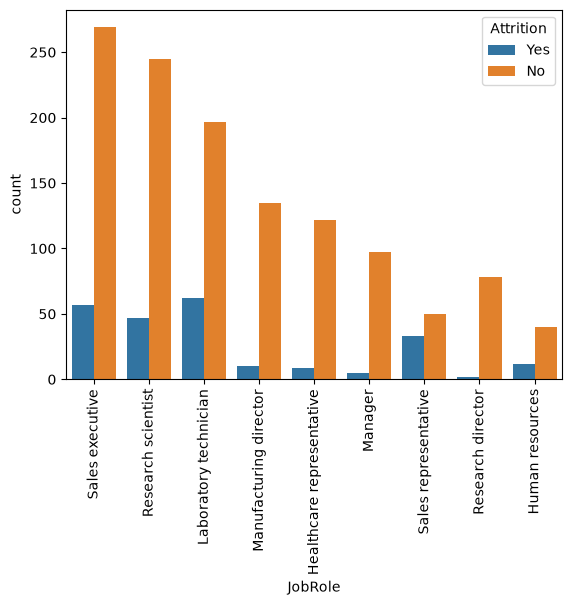

In [42]:
sns.countplot(
    data=df,
    x="JobRole",
    hue="Attrition"
)
plt.xticks(rotation=90)

In [43]:
df['JobRole'].value_counts()

JobRole
Sales executive              326
Research scientist           292
Laboratory technician        259
Manufacturing director       145
Healthcare representative    131
Manager                      102
Sales representative          83
Research director             80
Human resources               52
Name: count, dtype: int64

- 

# Género *

In [44]:
df['Gender'].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

In [45]:
pd.crosstab(
    df["Gender"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
Gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


<Axes: xlabel='Gender', ylabel='count'>

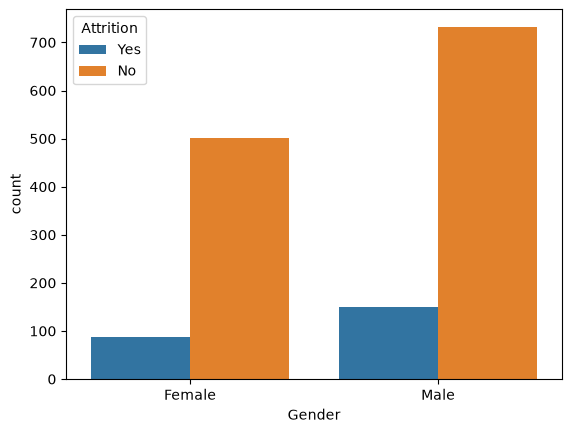

In [46]:
sns.countplot(
    data=df,
    x="Gender",
    hue="Attrition"
)

In [47]:
(df_attrition_yes['Gender'].value_counts(normalize=True).sort_index() * 100).round(2)

Gender
Female    36.71
Male      63.29
Name: proportion, dtype: float64

In [48]:
(df_attrition_no['Gender'].value_counts(normalize=True).sort_index() * 100).round(2)

Gender
Female    40.63
Male      59.37
Name: proportion, dtype: float64

# Estado civil

In [49]:
pd.crosstab(
    df["MaritalStatus"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
MaritalStatus,,
Divorced,89.189189,10.810811
Married,87.293729,12.706271
Single,74.311927,25.688073
Unknown,87.878788,12.121212


<Axes: xlabel='MaritalStatus', ylabel='count'>

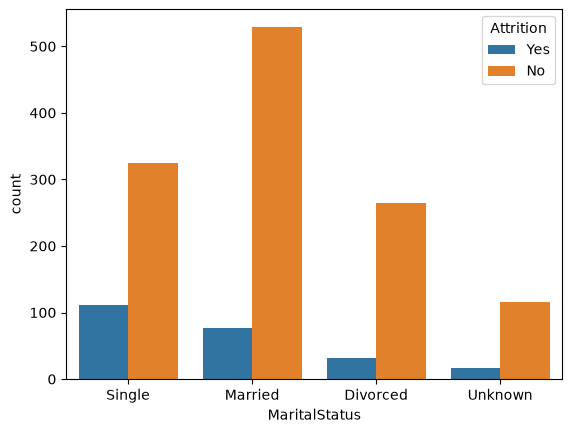

In [50]:
sns.countplot(
    data=df,
    x="MaritalStatus",
    hue="Attrition"
)

In [51]:
(df_attrition_no['MaritalStatus'].value_counts(normalize=True).sort_index() * 100).round(2)

MaritalStatus
Divorced    21.41
Married     42.90
Single      26.28
Unknown      9.41
Name: proportion, dtype: float64

In [52]:
(df_attrition_yes['MaritalStatus'].value_counts(normalize=True).sort_index() * 100).round(2)

MaritalStatus
Divorced    13.50
Married     32.49
Single      47.26
Unknown      6.75
Name: proportion, dtype: float64

- Mayormente casados

# Distancia al trabajo *

In [53]:
df_attrition_no['DistanceFromHome'].value_counts()

DistanceFromHome
2     183
1     182
10     75
7      73
8      70
3      70
9      67
5      55
4      55
6      52
16     25
11     25
23     22
26     22
18     22
29     22
15     21
20     21
28     21
19     19
25     19
14     17
24     16
21     15
17     15
12     14
22     13
13     13
27      9
Name: count, dtype: int64

In [54]:
df_attrition_yes['DistanceFromHome'].value_counts()

DistanceFromHome
2     28
1     26
9     18
3     14
24    12
7     11
10    11
5     10
8     10
4      9
6      7
16     7
25     6
12     6
22     6
13     6
23     5
29     5
15     5
17     5
14     4
20     4
18     4
11     4
27     3
26     3
19     3
21     3
28     2
Name: count, dtype: int64

<Axes: xlabel='DistanceFromHome', ylabel='Attrition'>

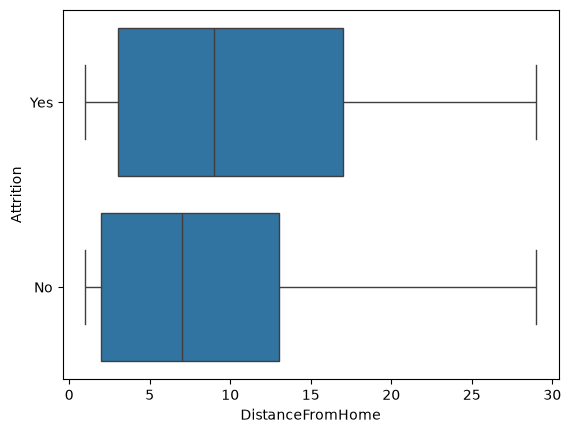

In [55]:
sns.boxplot(
    data=df,
    y="Attrition",
    x="DistanceFromHome"
)

In [56]:
df.groupby("Attrition")["DistanceFromHome"].agg(["mean","median"])

,mean,median
Attrition,,
No,8.915653,7.0
Yes,10.632911,9.0


- La distancia media al trabajo es mayor entre los empleados que abandonan la empresa.

# Años en la empresa

In [57]:
df['YearsAtCompany'].min()

np.int64(0)

In [58]:
df.groupby("Attrition")["YearsAtCompany"].agg(["mean","median"])

,mean,median
Attrition,,
No,7.369019,6.0
Yes,5.130802,3.0


<Axes: xlabel='Attrition', ylabel='YearsAtCompany'>

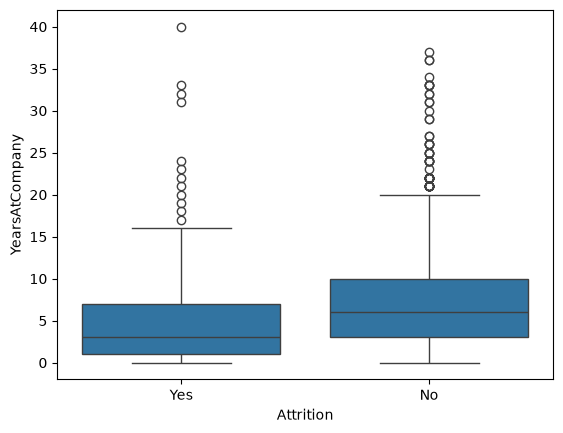

In [59]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

- Se van mas los que llevan menos años en la empresa 

# Viajes

In [60]:
pd.crosstab(
    df["BusinessTravel"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
BusinessTravel,,
Non-Travel,91.366906,8.633094
Travel_Frequently,75.285171,24.714829
Travel_Rarely,85.594111,14.405889
Unknown,80.341880,19.658120


<Axes: xlabel='BusinessTravel', ylabel='count'>

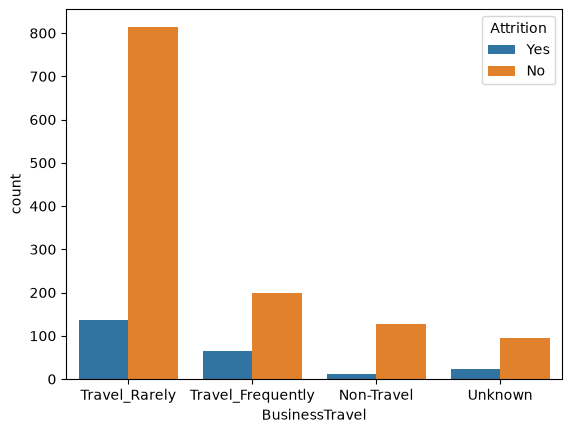

In [61]:
sns.countplot(
    data=df,
    x="BusinessTravel",
    hue="Attrition"
)

- 